# **Final Project Task 2 - Census EDA**

Requirements

- Analyze hours-per-week Target Distribution **1p**
    - Provide visualizations like histograms or density plots for hours-per-week to assess its distribution, outliers, and skewness.

- Provide a summary of the dataset using descriptive statistics, such as mean, median, and standard deviation. **1p**

- Check for missing values and report the number and percentage of missing data for each column. **1p**

- Identify outliers in at least one numerical column using boxplots. **1p**

- Write a summary report of your findings from the EDA, highlighting key patterns or trends, unexpected insights or anomalies, and areas requiring further investigation. **1p**


- Plot histograms for at least three numerical columns and discuss their distributions, such as skewness and modality. - Optional

- Generate bar plots for at least three categorical columns and discuss the frequency distributions. - Optional

- Create a correlation matrix for target hours-per-week and the rest of numerical variables and discuss the strongest and weakest correlations with the target. - Optional

- Explore relationships between at least one numerical variable and hours-per-week target using scatter plots and identify any visible trends. Choose the variable that is/are most correlated with hours-per-week. - Optional

- Analyze the relationship between hours-per-week and all categorical variable using boxplots or violin plots. - Optional

- At the end, do the same analysis for the preprocessed dataset (just change the input data in the EDA), and write a report. - Optional

- Others? - Optional


Deliverable:

- Notebook code with no errors.
- Include all visuals from the requirements in the notebook: graphs, plots, histograms, heatmap etc
- Be sure to discuss the findings and add a summary report

In [1]:
import pandas as pd

In [2]:
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

data = pd.read_csv(data_url, header=None, names=columns, na_values=" ?", skipinitialspace=True)
data.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
6506,25,Private,315643,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,30,United-States,<=50K
14742,31,?,163890,Some-college,10,Never-married,?,Unmarried,Black,Female,0,0,40,United-States,<=50K
5866,51,Self-emp-not-inc,25932,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,60,United-States,<=50K
6791,17,Private,110723,11th,7,Never-married,Sales,Own-child,White,Female,0,0,25,United-States,<=50K
29958,53,Private,312446,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K
4936,46,Federal-gov,340718,11th,7,Widowed,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
4306,30,Private,65278,HS-grad,9,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
29750,45,Local-gov,172111,Bachelors,13,Divorced,Exec-managerial,Unmarried,Black,Female,0,0,60,United-States,<=50K
6724,40,Self-emp-not-inc,99651,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,<=50K
5966,45,Self-emp-not-inc,242552,12th,8,Divorced,Craft-repair,Other-relative,Black,Male,0,0,35,United-States,<=50K


Importuri

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setări vizuale
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


Incarcare dataset


In [4]:
# Dataset original (Adult)
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

data = pd.read_csv(
    data_url,
    header=None,
    names=columns,
    na_values=" ?",
    skipinitialspace=True
)


Target distribution

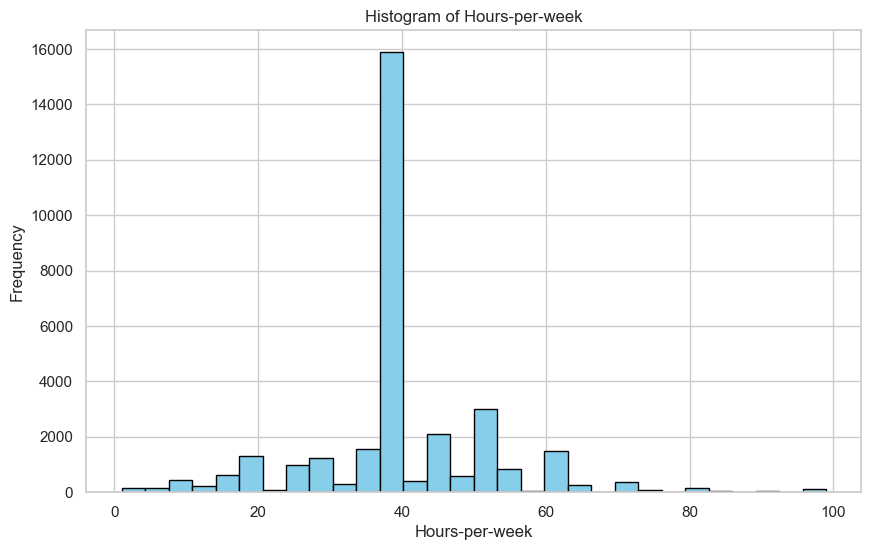

C:\Users\10\AppData\Local\Temp\ipykernel_22088\355427701.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data["hours-per-week"], shade=True, color="red")


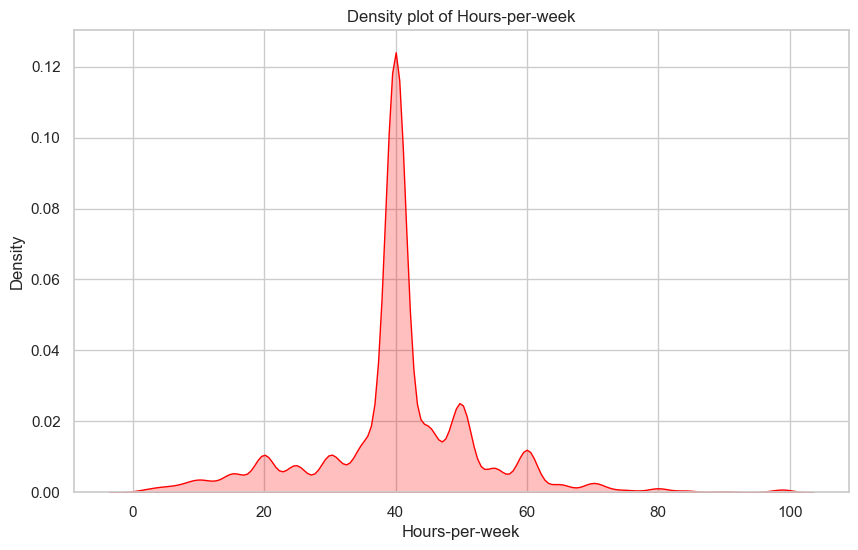

In [5]:
# Histogram
plt.hist(data["hours-per-week"], bins=30, color="skyblue", edgecolor="black")
plt.title("Histogram of Hours-per-week")
plt.xlabel("Hours-per-week")
plt.ylabel("Frequency")
plt.show()

# Density plot
sns.kdeplot(data["hours-per-week"], shade=True, color="red")
plt.title("Density plot of Hours-per-week")
plt.xlabel("Hours-per-week")
plt.show()


### Analysis of Target: Hours-per-week

- Histogram shows a clear peak at 40 hours, indicating that most individuals work full-time.  
- There are some extreme values above 60 hours/week, considered potential outliers.  
- A few individuals work under 20 hours/week, likely representing part-time employment.  
- Overall, the distribution is unimodal and slightly skewed to the right, suggesting the presence of high-hour outliers.  


Descriptive statistics

In [6]:
data["hours-per-week"].describe()


count    32561.000000
mean        40.437456
std         12.347429
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

In [7]:
mean_hp = data["hours-per-week"].mean()
median_hp = data["hours-per-week"].median()
std_hp = data["hours-per-week"].std()

print(f"Mean: {mean_hp:.2f}, Median: {median_hp}, Std: {std_hp:.2f}")


Mean: 40.44, Median: 40.0, Std: 12.35


### Target Variable Analysis: Hours-per-week

- The mean of `hours-per-week` is 40.44, while the median is 40.  
- The fact that the mean is slightly higher than the median indicates a **right-skewed distribution**, caused by a small number of individuals working significantly more than 40 hours per week.  
- Most people work around 40 hours, confirming that the data is concentrated around the standard full-time workweek.  
- This small positive skew suggests the presence of **high-hour outliers**, but they do not drastically affect the central tendency of the data.


Check Missing Values

In [8]:
missing_count = data.isnull().sum()
missing_percent = (missing_count / len(data)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_df


,Missing Count,Missing %
age,0,0.0
workclass,0,0.0
fnlwgt,0,0.0
education,0,0.0
education-num,0,0.0
marital-status,0,0.0
occupation,0,0.0
relationship,0,0.0
race,0,0.0
sex,0,0.0


Outlier detection

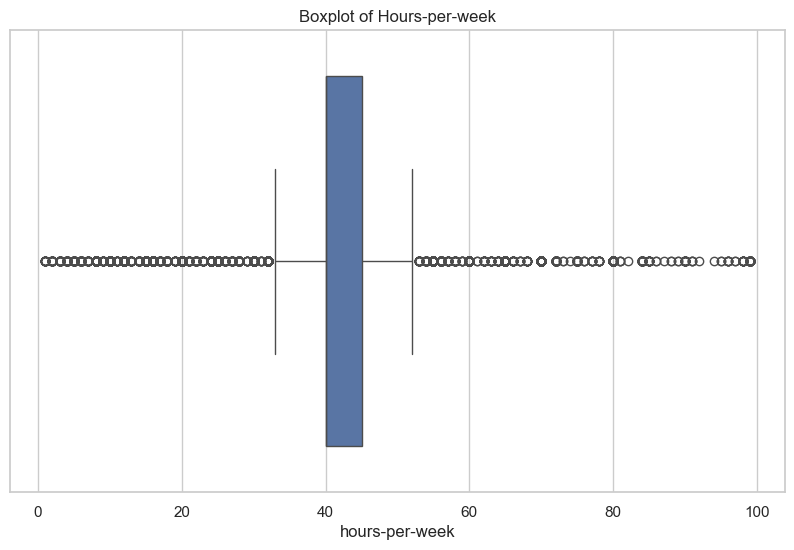

In [9]:
sns.boxplot(x=data["hours-per-week"])
plt.title("Boxplot of Hours-per-week")
plt.show()


### Outlier Analysis: Hours-per-week

- The boxplot shows that the median of `hours-per-week` is around 40 hours, confirming that most individuals work a standard full-time schedule.  
- The interquartile range (IQR) is relatively narrow, indicating that the majority of observations are concentrated around the median.  
- Several outliers are visible on both ends of the distribution.  
- Low-end outliers (below 20 hours per week) likely represent part-time workers.  
- High-end outliers (above 60 hours per week, reaching up to 99 hours) indicate individuals working exceptionally long hours.  
- These outliers contribute to the slight right skew observed in the distribution and may influence the mean value.


Descriptive statistics

In [10]:
mean_hp = data["hours-per-week"].mean()
median_hp = data["hours-per-week"].median()
std_hp = data["hours-per-week"].std()
min_hp = data["hours-per-week"].min()
max_hp = data["hours-per-week"].max()

print(f"Mean: {mean_hp:.2f}")
print(f"Median: {median_hp}")
print(f"Standard Deviation: {std_hp:.2f}")
print(f"Min: {min_hp}")
print(f"Max: {max_hp}")


Mean: 40.44
Median: 40.0
Standard Deviation: 12.35
Min: 1
Max: 99


### Summary Statistics for Hours-per-week

- The mean number of working hours per week is 40.44, while the median is 40 hours.  
- The close proximity of the mean and median indicates that the distribution is centered around the standard full-time work schedule.  
- The standard deviation of 12.35 suggests a moderate level of variability in weekly working hours.  
- The minimum value of 1 hour per week indicates very low levels of work activity, likely corresponding to part-time or marginal employment.  
- The maximum value of 99 hours per week highlights the presence of extreme cases, confirming the existence of high-end outliers in the dataset.  
- Overall, the distribution shows a slight right skew, driven by individuals working unusually long hours.


Histograme

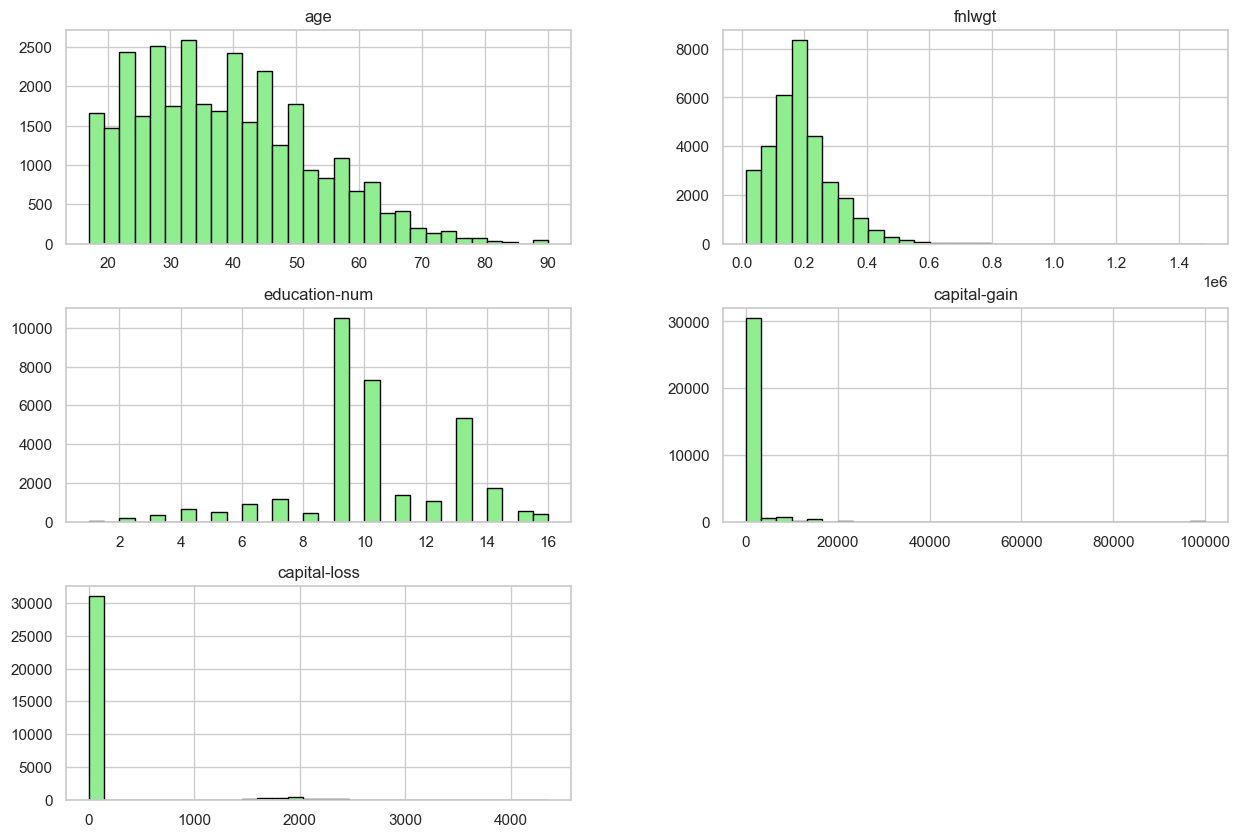

In [11]:
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss"]
data[numeric_cols].hist(bins=30, figsize=(15,10), color='lightgreen', edgecolor='black')
plt.show()


### Distribution Analysis of Key Variables

**Age**  
The age distribution is right-skewed, with the majority of individuals concentrated between approximately 25 and 50 years old. The frequency decreases steadily after the age of 60, indicating fewer observations among older age groups. This suggests that the dataset is dominated by working-age individuals.

**Final Weight (fnlwgt)**  
The distribution of `fnlwgt` is strongly right-skewed, with most observations clustered at lower values and a long tail extending toward higher weights. This behavior is expected, as the variable represents population weights rather than a natural measurement.

**Education-num**  
The variable `education-num` shows a discrete distribution with clear peaks, particularly around values corresponding to high school and bachelor-level education. This indicates that a large proportion of individuals have mid-level to higher education, while very low and very high education levels are less frequent.

**Capital Gain**  
The `capital-gain` variable is extremely right-skewed, with the vast majority of observations concentrated at zero. Only a small number of individuals report positive capital gains, and a few extreme values create a long right tail, indicating the presence of significant outliers.

**Capital Loss**  
Similar to capital gain, `capital-loss` is highly skewed toward zero. Most individuals report no capital losses, while a limited number of observations exhibit positive values, again suggesting sparsity and the presence of outliers.


Bar plots

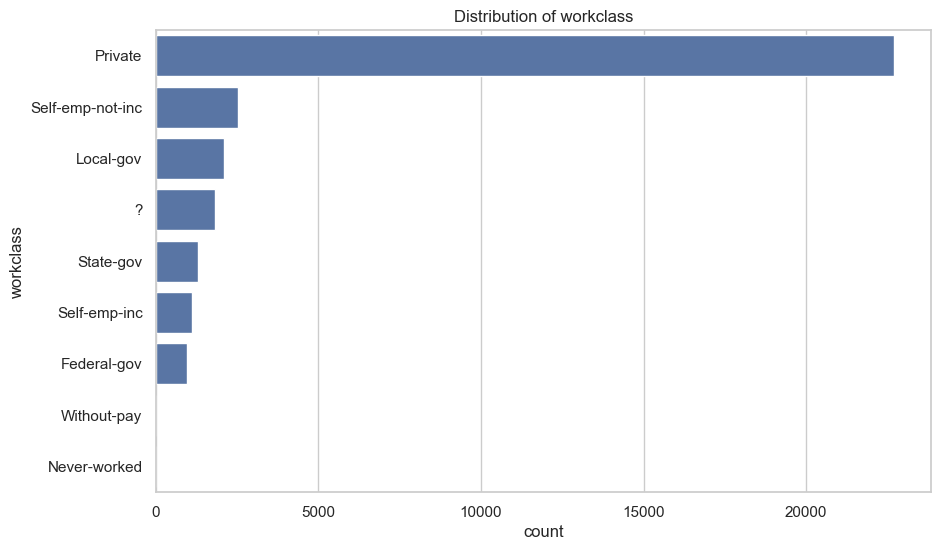

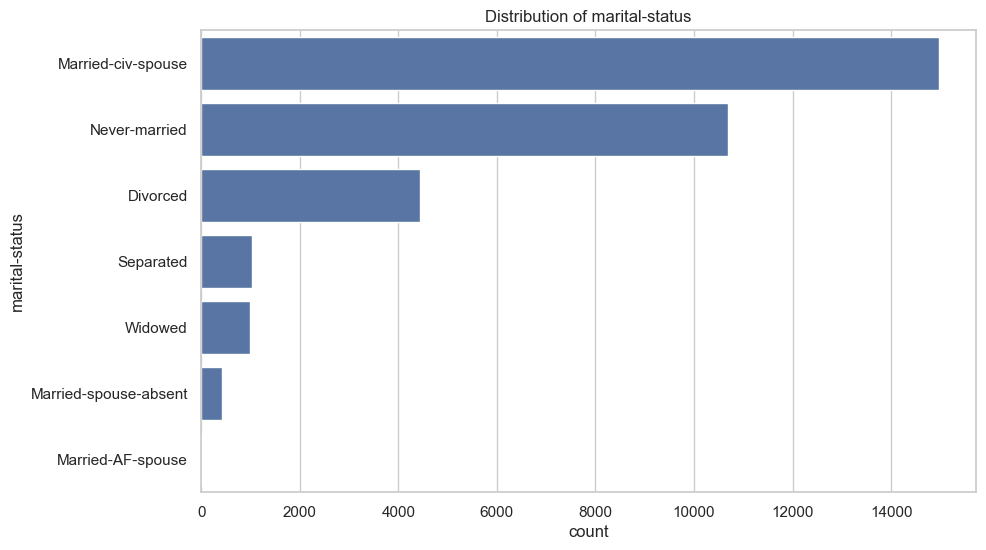

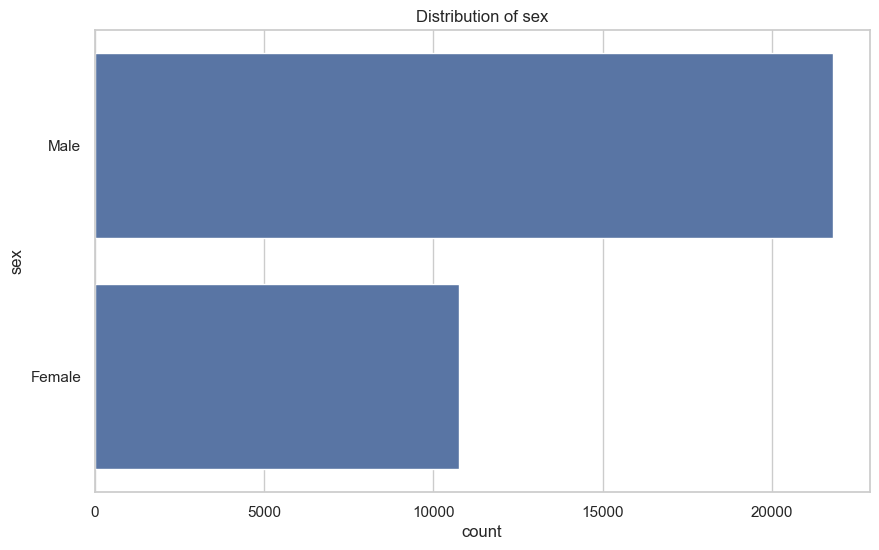

In [12]:
categorical_cols = ["workclass", "marital-status", "sex"]

for col in categorical_cols:
    sns.countplot(y=data[col], order=data[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()


---The distribution of marital status shows that Married individuals represent the largest group in the dataset. This suggests that the sample is dominated by people who are married, which may influence other variables such as income, working hours, or employment stability.

---Regarding gender, men are more prevalent than women in the dataset. This imbalance indicates that the sample slightly overrepresents male respondents, which should be taken into account when interpreting gender-related results or drawing broader conclusions.

---Overall, both distributions highlight potential demographic imbalances that may affect downstream analysis and should be considered when building models or interpreting outcomes

Correlation

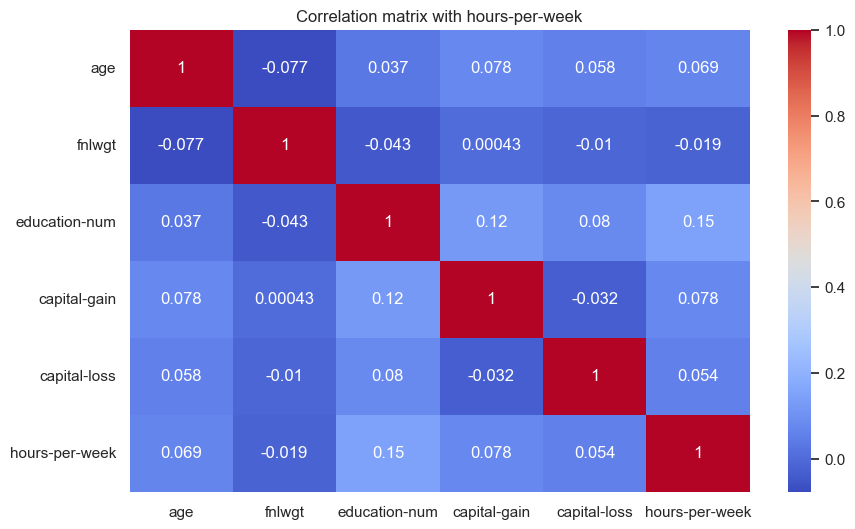

In [13]:
corr = data[numeric_cols + ["hours-per-week"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation matrix with hours-per-week")
plt.show()


The correlation matrix indicates that hours per week has generally weak correlations with the other numerical variables in the dataset.

The strongest relationship is observed with education level (education-num), showing a small positive correlation (r ≈ 0.15). This suggests that individuals with higher education levels tend to work slightly more hours per week.

Age has a very weak positive correlation (r ≈ 0.07) with hours worked, indicating that older individuals may work marginally more hours, but the effect is minimal.

Capital gain and capital loss both show very weak positive correlations with hours per week, implying almost no linear relationship.

Final weight (fnlwgt) has a negligible negative correlation, meaning it has no meaningful association with working hours.

Overall, none of the variables exhibit a strong linear relationship with hours-per-week. This suggests that working hours are likely influenced by other factors (possibly categorical variables such as occupation or workclass) rather than the numerical features analyzed here.

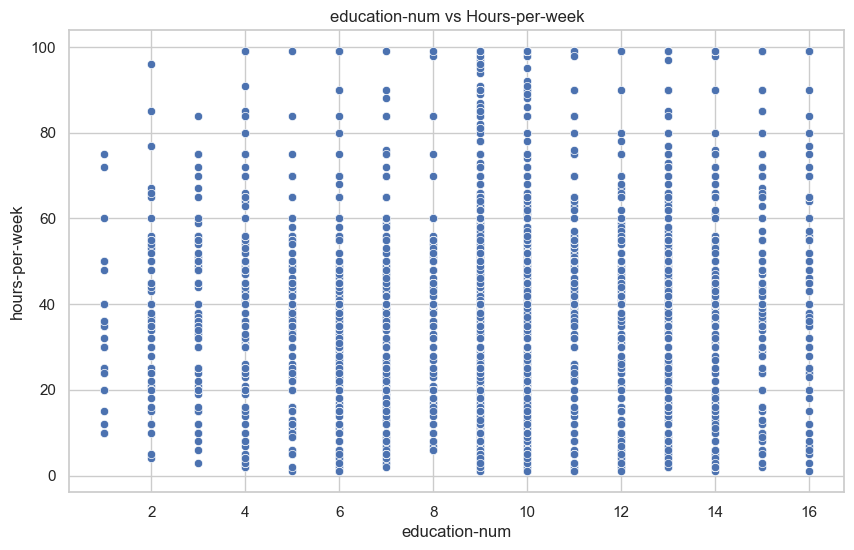

In [14]:

sns.scatterplot(x="education-num", y="hours-per-week", data=data)
plt.title("education-num vs Hours-per-week")
plt.show()


---there is no strong linear relationship

---There is a very high density of points across all education levels at the 40-hour mark, reflecting the standard full-time work week.

---for levels 13 through 16 (higher education), the density of points above 40 hours appears slightly thicker compared to the lower levels (1–8).
This suggests that individuals with higher degrees are frequently represented in roles requiring 50–80 hours per week.


---Every education level has "extreme" workers hitting the 100-hour cap, though these are less frequent at the very lowest education levels (e.g., level 1)

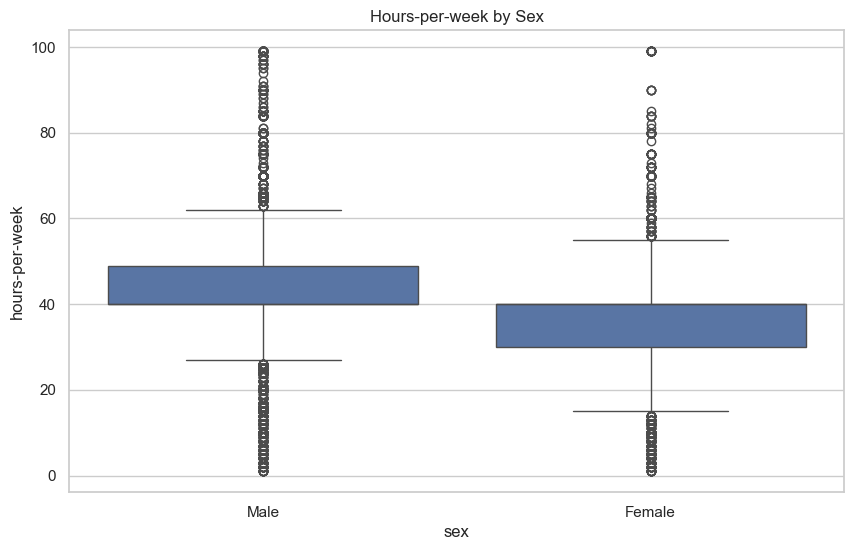

In [15]:
sns.boxplot(x="sex", y="hours-per-week", data=data)
plt.title("Hours-per-week by Sex")
plt.show()


---Male: The box is narrower and positioned higher, with the bottom at 40 and the top near 50 hours per week.

---Female: The box is wider and lower, spanning from approximately 30 to 40 hours per week.

---The median for males sits right at 40 hours, which is also the bottom of their box (suggesting a massive concentration of data at exactly 40).

---The median for females is lower, appearing to be around 35–38 hours